# Las píldoras anti-obesidad pasan por la amígdala

**Ozempic se inyecta. Las pastillas que vienen — Danuglipron, Orforglipron — usan otra ruta.**

Funcionan igual de bien para reducir el peso, pero su efecto pasa por un nodo cerebral inesperado: la amígdala central, el mismo lugar donde el cerebro decide si una comida es placer o sustento.

[![Open in Colab]({colab_badge})](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-glp1-amigdala-recompensa-ratones/notebook.ipynb)

📄 **Paper**: [A brain reward circuit inhibited by next-generation weight-loss drugs in mice](https://doi.org/10.1038/s41586-026-10444-4)  ·  *Nature, 2026*
🎥 **Video**: [Ver en YouTube](https://youtube.com/shorts/tczOa5XGGrU)
🐙 **Repo**: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## El problema con las pastillas

Liraglutide (la inyección semanal tipo Ozempic) reduce el peso activando un receptor — el **Glp1r** — que está en tu cerebro y en el de los ratones. Por eso se pudo estudiar en ratones décadas antes de probarse en humanos.

Las pastillas de nueva generación tienen un problema técnico: solo se unen al receptor humano. Cambia *un* aminoácido en la posición 33 — triptófano (W) en ratones, serina (S) en humanos — y la pastilla deja de funcionar. Para estudiar el mecanismo en ratones, el equipo creó una línea genética con la mutación humana: **ratones S33W** que sí responden a las pastillas.

Lo que encontraron al comparar las inyectables con las pastillas: actúan sobre la **misma señal pero diferente circuito**. Las pastillas reclutan la amígdala central — un nodo del sistema de recompensa que las inyectables apenas tocan.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TIEMPO_FOCO = '2hr'             # Ventana temporal a analizar (1hr, 2hr, 4hr)
FUENTE = 'Fuente: Nature (2026) · doi.org/10.1038/s41586-026-10444-4 | Datos: Source Data Figs 1, 3 y 4'
COLOR_WT = '#94A3B8'            # gris azulado — receptor murino
COLOR_S33W = '#2563EB'          # azul CaM — receptor humanizado
COLOR_ALERTA = '#DC2626'        # rojo — comida palatable / efecto clave
COLOR_HOMEOSTAT = '#059669'     # emerald — circuito homeostático
COLOR_REF = '#D97706'           # ámbar — referencia/umbral

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM — buscar local → fallback GitHub raw
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga datos
df_ingesta = pd.read_csv('datos/ingesta_droga_genotipo.csv')
df_fos = pd.read_csv('datos/fos_region_cerebral.csv')
df_aav = pd.read_csv('datos/rescate_aav_completo.csv')

print(f'Ingesta: {len(df_ingesta)} filas · drogas: {sorted(df_ingesta.droga.unique())}')
print(f'Fos:     {len(df_fos)} ratones · regiones: {sorted(df_fos.region.unique())}')
print(f'Rescate: {len(df_aav)} filas · regiones AAV: {sorted(df_aav.region_aav.unique())}')

Ingesta: 36 filas · drogas: ['Danuglipron', 'Liraglutide', 'Orforglipron']
Fos:     120 ratones · regiones: ['AP', 'CEA', 'DMH', 'NTS']
Rescate: 455 filas · regiones AAV: ['CeA', 'DMH', 'Hypothalamus', 'Hypothalamus mCherry', 'NTS/AP']


## Lo que hace cada droga, sin filtros

A las 2 horas de la inyección, midieron cuánta comida había consumido cada ratón comparado con su control salino. Tres drogas, dos genotipos.

       droga genotipo  pct_cambio   sem_pct  n_drug  n_ctrl
 Liraglutide       WT  -51.941748  9.304757      10      11
 Liraglutide     S33W  -56.701031 10.281460       9       9
 Danuglipron       WT   10.619469 12.728650      16      16
 Danuglipron     S33W  -51.492537  9.637869      15      15
Orforglipron       WT   -1.162791 10.713319       8       8
Orforglipron     S33W  -57.575758  8.125425       9       9


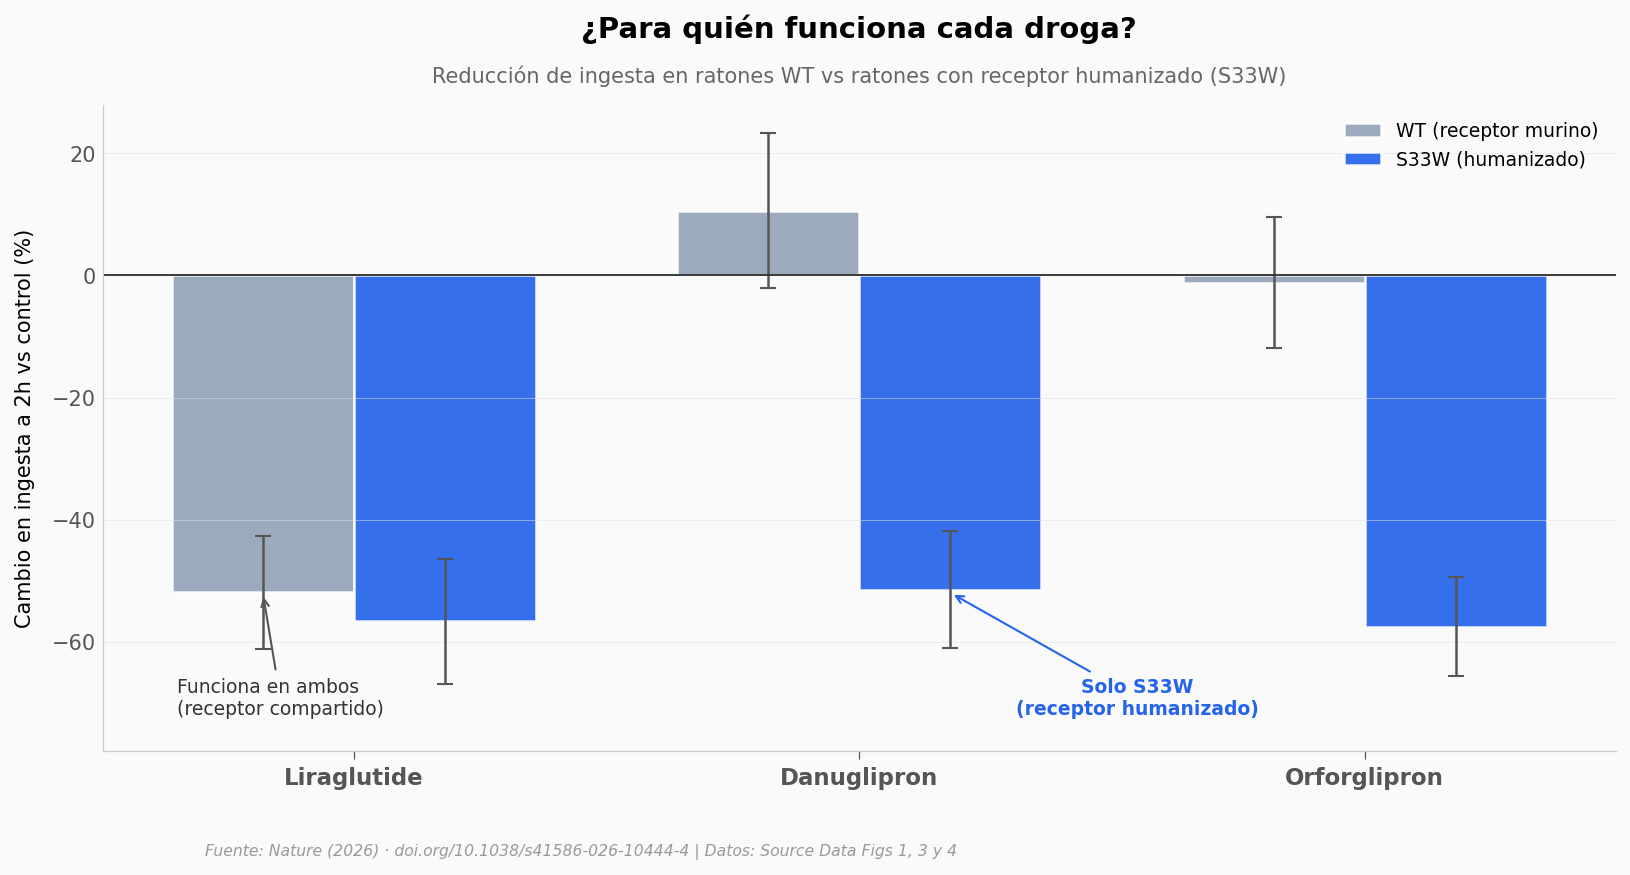

In [2]:
# Calcular % cambio respecto a control para cada (droga, genotipo) a 2hr
drogas = ['Liraglutide', 'Danuglipron', 'Orforglipron']
genotipos = ['WT', 'S33W']

resultados = []
for droga in drogas:
    for geno in genotipos:
        ctrl = df_ingesta[(df_ingesta.tiempo==TIEMPO_FOCO)&(df_ingesta.droga==droga)&
                          (df_ingesta.genotipo==geno)&(df_ingesta.condicion=='control')]
        drug = df_ingesta[(df_ingesta.tiempo==TIEMPO_FOCO)&(df_ingesta.droga==droga)&
                          (df_ingesta.genotipo==geno)&(df_ingesta.condicion=='droga')]
        m_c, s_c, n_c = ctrl.media_ingesta_g.values[0], ctrl.sem_ingesta_g.values[0], ctrl.n.values[0]
        m_d, s_d, n_d = drug.media_ingesta_g.values[0], drug.sem_ingesta_g.values[0], drug.n.values[0]
        pct = (m_d - m_c) / m_c * 100
        # SEM propagado del cociente (delta method)
        sem_pct = 100 * np.sqrt((s_d / m_c)**2 + (m_d * s_c / m_c**2)**2)
        resultados.append({'droga': droga, 'genotipo': geno, 'pct_cambio': pct,
                           'sem_pct': sem_pct, 'n_drug': int(n_d), 'n_ctrl': int(n_c)})
res = pd.DataFrame(resultados)
print(res.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(drogas))
width = 0.36

for i, geno in enumerate(genotipos):
    sub = res[res.genotipo == geno]
    offset = -width/2 if geno == 'WT' else width/2
    color = COLOR_WT if geno == 'WT' else COLOR_S33W
    bars = ax.bar(x + offset, sub.pct_cambio.values, width,
                  yerr=sub.sem_pct.values, capsize=4,
                  color=color, alpha=0.92, edgecolor='white', linewidth=1.2,
                  error_kw={'elinewidth': 1.2, 'ecolor': '#555555'},
                  label=f'{geno} (receptor murino)' if geno == 'WT' else f'{geno} (humanizado)')

ax.axhline(0, color='#333333', linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(drogas, fontsize=11, fontweight='bold')
ax.set_ylabel('Cambio en ingesta a 2h vs control (%)', fontsize=10)
ax.set_title('¿Para quién funciona cada droga?',
             fontsize=14, fontweight='bold', pad=32)
ax.text(0.5, 1.035, 'Reducción de ingesta en ratones WT vs ratones con receptor humanizado (S33W)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.95)
ax.set_ylim(-78, 28)

# Anotaciones clave (debajo de las barras, separadas de la leyenda)
ax.annotate('Funciona en ambos\n(receptor compartido)',
            xy=(-width/2, -52), xytext=(-0.35, -72),
            fontsize=9, color='#333333', ha='left',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1))
ax.annotate('Solo S33W\n(receptor humanizado)',
            xy=(1 + width/2, -52), xytext=(1.55, -72),
            fontsize=9, color=COLOR_S33W, ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_S33W, lw=1))

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_especificidad_drogas.png', dpi=200, bbox_inches='tight')
plt.show()

**Liraglutide funciona casi idéntico en los dos genotipos** (-52% en WT, -57% en S33W) porque el péptido se une a ambas versiones del receptor. Es el control positivo: si la pastilla funcionara igual, las dos barras de Danuglipron también serían iguales.

No lo son. **Danuglipron reduce la ingesta un 52% en S33W (Cohen's d = -1.39, efecto grande) pero la sube un 11% en WT (d = +0.31, ruido).** No hay error de medición: el receptor murino simplemente no reconoce la molécula. Orforglipron muestra el mismo patrón aún más nítido (~58% en S33W, ~1% en WT).

La conclusión técnica: cualquier efecto cerebral que veamos con Danuglipron u Orforglipron en ratones S33W es **atribuible al receptor humanizado**, no a efectos inespecíficos. Eso convierte a estos ratones en una sonda válida para preguntar dónde actúan estas drogas.

## ¿Dónde encienden el cerebro?

Si las pastillas funcionan vía el receptor humanizado, ¿qué regiones del cerebro se activan más en S33W que en WT bajo la misma dosis de Danuglipron? Para medirlo, el equipo cuantificó **Fos** — una proteína que marca neuronas que dispararon recientemente — en cuatro regiones candidatas.

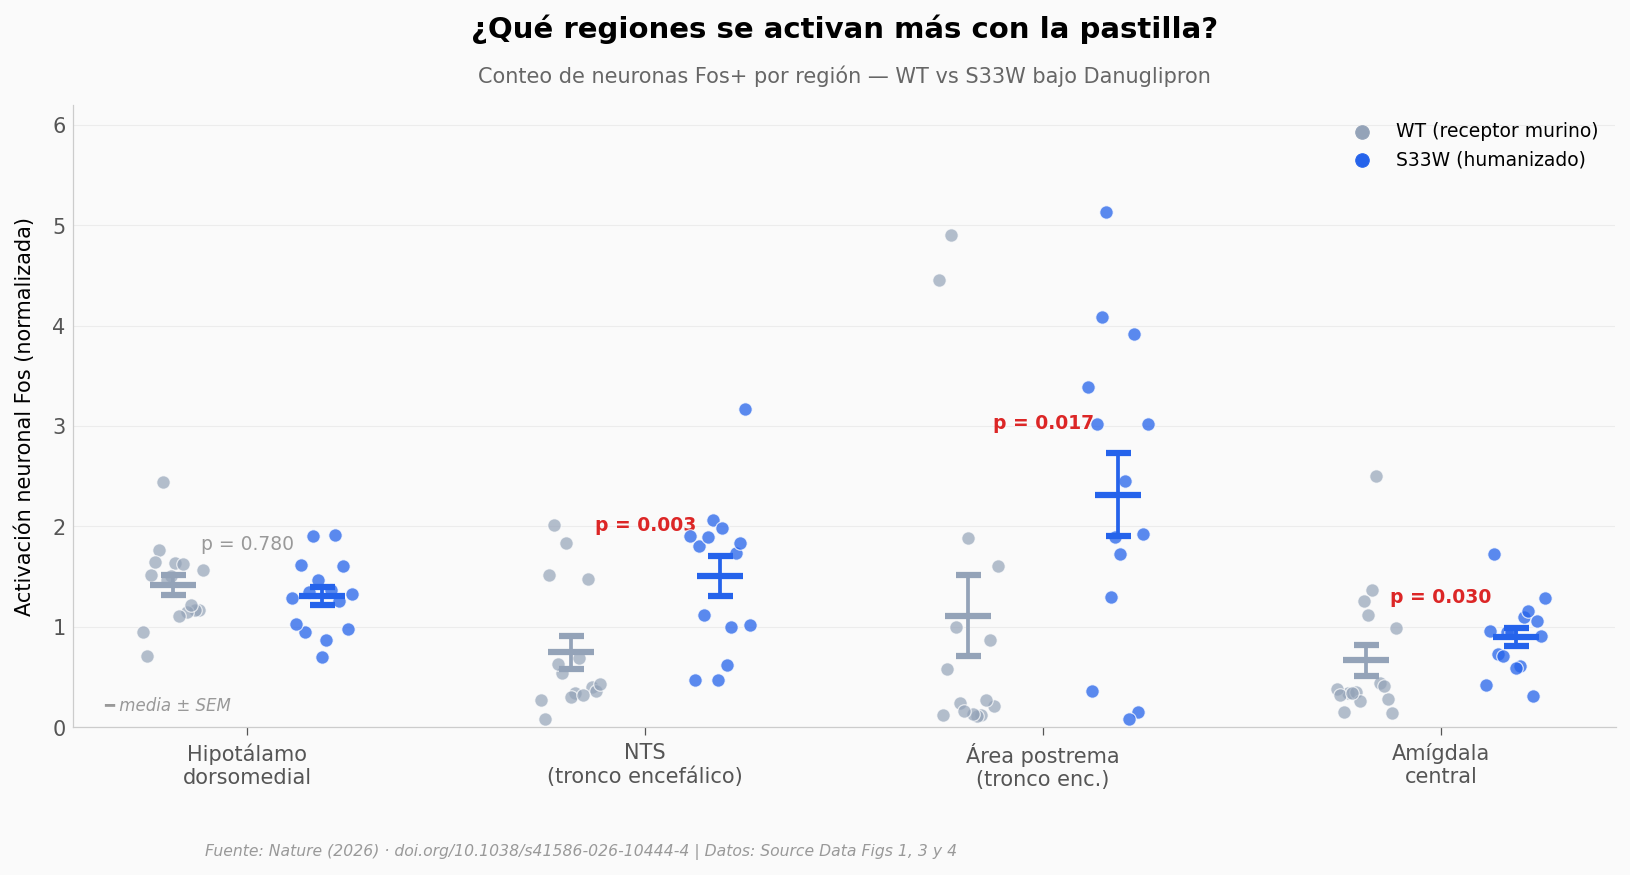


=== Estadísticas Fos (Mann-Whitney one-sided S33W > WT) ===
region  n_wt  n_s33w  media_wt  media_s33w  p_mannwhitney  cohens_d
   DMH    16      15  1.414617    1.307669       0.779589 -0.280193
   NTS    15      14  0.746933    1.504647       0.002791  1.091587
    AP    15      14  1.109235    2.316834       0.017142  0.779408
   CEA    16      15  0.665069    0.897178       0.030218  0.447750


In [3]:
# Strip plot Fos por región × genotipo + Mann-Whitney
regiones = ['DMH', 'NTS', 'AP', 'CEA']
nombres = {'DMH': 'Hipotálamo\ndorsomedial',
           'NTS': 'NTS\n(tronco encefálico)',
           'AP':  'Área postrema\n(tronco enc.)',
           'CEA': 'Amígdala\ncentral'}

fig, ax = plt.subplots(figsize=(11, 5.5))
np.random.seed(42)
positions = []
stats_resumen = []
for i, region in enumerate(regiones):
    pos_wt = i * 2.4
    pos_s33w = i * 2.4 + 0.9
    positions.extend([pos_wt, pos_s33w])

    vals_wt = df_fos[(df_fos.region == region) & (df_fos.genotipo == 'WT')]['fos_norm'].values
    vals_s33w = df_fos[(df_fos.region == region) & (df_fos.genotipo == 'S33W')]['fos_norm'].values

    # Mann-Whitney (one-sided: S33W > WT esperado)
    u, p = stats.mannwhitneyu(vals_s33w, vals_wt, alternative='greater')
    pooled = np.sqrt((vals_wt.var(ddof=1)*(len(vals_wt)-1) + vals_s33w.var(ddof=1)*(len(vals_s33w)-1))
                     / (len(vals_wt) + len(vals_s33w) - 2))
    d = (vals_s33w.mean() - vals_wt.mean()) / pooled
    stats_resumen.append({'region': region, 'n_wt': len(vals_wt), 'n_s33w': len(vals_s33w),
                          'media_wt': vals_wt.mean(), 'media_s33w': vals_s33w.mean(),
                          'p_mannwhitney': p, 'cohens_d': d})

    # Strip plot WT
    n = len(vals_wt)
    x_strip = np.linspace(pos_wt - 0.18, pos_wt + 0.18, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals_wt, color=COLOR_WT, s=42, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5)
    ax.errorbar(pos_wt, vals_wt.mean(), yerr=vals_wt.std(ddof=1)/np.sqrt(n),
                fmt='_', color=COLOR_WT, markersize=22, markeredgewidth=3,
                capsize=6, capthick=1.5, zorder=6)

    # Strip plot S33W
    n2 = len(vals_s33w)
    x_strip2 = np.linspace(pos_s33w - 0.18, pos_s33w + 0.18, n2)
    np.random.shuffle(x_strip2)
    ax.scatter(x_strip2, vals_s33w, color=COLOR_S33W, s=42, alpha=0.75,
               edgecolors='white', linewidths=0.6, zorder=5)
    ax.errorbar(pos_s33w, vals_s33w.mean(), yerr=vals_s33w.std(ddof=1)/np.sqrt(n2),
                fmt='_', color=COLOR_S33W, markersize=22, markeredgewidth=3,
                capsize=6, capthick=1.5, zorder=6)

    # Anotación significancia (entre las dos columnas del grupo, encima de la media + SEM)
    y_top = max(vals_s33w.mean() + vals_s33w.std(ddof=1)/np.sqrt(n2),
                vals_wt.mean() + vals_wt.std(ddof=1)/np.sqrt(n)) + 0.25
    label_p = f'p = {p:.3f}' if p >= 0.001 else f'p < 0.001'
    color_p = COLOR_ALERTA if p < 0.05 else '#999999'
    weight_p = 'bold' if p < 0.05 else 'normal'
    ax.text((pos_wt + pos_s33w)/2, y_top, label_p,
            ha='center', fontsize=9, color=color_p, fontweight=weight_p)

# X axis labels
tick_positions = [i * 2.4 + 0.45 for i in range(len(regiones))]
ax.set_xticks(tick_positions)
ax.set_xticklabels([nombres[r] for r in regiones], fontsize=10)

ax.set_ylabel('Activación neuronal Fos (normalizada)', fontsize=10)
ax.set_title('¿Qué regiones se activan más con la pastilla?',
             fontsize=14, fontweight='bold', pad=32)
ax.text(0.5, 1.035, 'Conteo de neuronas Fos+ por región — WT vs S33W bajo Danuglipron',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 6.2)

# Leyenda manual con texto coloreado (esquina inferior derecha para no chocar con datos arriba)
ax.scatter([], [], color=COLOR_WT, s=42, label='WT (receptor murino)')
ax.scatter([], [], color=COLOR_S33W, s=42, label='S33W (humanizado)')
ax.legend(fontsize=9, loc='upper right', framealpha=0.95)

# Nota explicativa error bars (esquina inferior izquierda)
ax.text(0.02, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='left', va='bottom', style='italic')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_fos_por_region.png', dpi=200, bbox_inches='tight')
plt.show()

print('\n=== Estadísticas Fos (Mann-Whitney one-sided S33W > WT) ===')
print(pd.DataFrame(stats_resumen).to_string(index=False))

La señal más interesante no es la más grande. **DMH** (hipotálamo dorsomedial) no muestra diferencia entre WT y S33W — sus neuronas ya respondían al GLP-1 que el propio cuerpo fabrica (endógeno) antes de la pastilla — el receptor humanizado no cambia mucho ahí. NTS y AP en el tronco encefálico sí se activan más. Y la **amígdala central (CeA)** — la región que no aparece en los modelos clásicos de control alimentario — también.

El efecto en CeA es modesto en magnitud (d = 0.45, "medio" en la escala de Cohen) pero **significativo y direccionalmente claro** (p = 0.030). La pregunta que sigue: ¿la CeA es necesaria para el efecto de la droga, o solo está "encendida" sin hacer nada?

Para responderlo, hace falta una intervención causal. El equipo usó vectores virales (AAV) para reintroducir el receptor humanizado **solo** en una región a la vez, y midió si la droga seguía reduciendo la ingesta — separando comida estándar (SD, sin recompensa especial) de dieta alta en grasa (HFD, palatable).

      region dieta  n  veh_mean  dan_mean  pct_cambio  p_wilcoxon
         CeA    SD  9  0.577778  0.577778    0.000000    0.937500
         CeA   HFD  8  1.162500  0.825000  -29.032258    0.031250
Hypothalamus    SD 10  0.860000  0.380000  -55.813953    0.007812
Hypothalamus   HFD 10  1.150000  0.990000  -13.913043    0.234375
      NTS/AP    SD  6  0.800000  0.583333  -27.083333    0.218750
      NTS/AP   HFD  6  1.316667  0.816667  -37.974684    0.031250


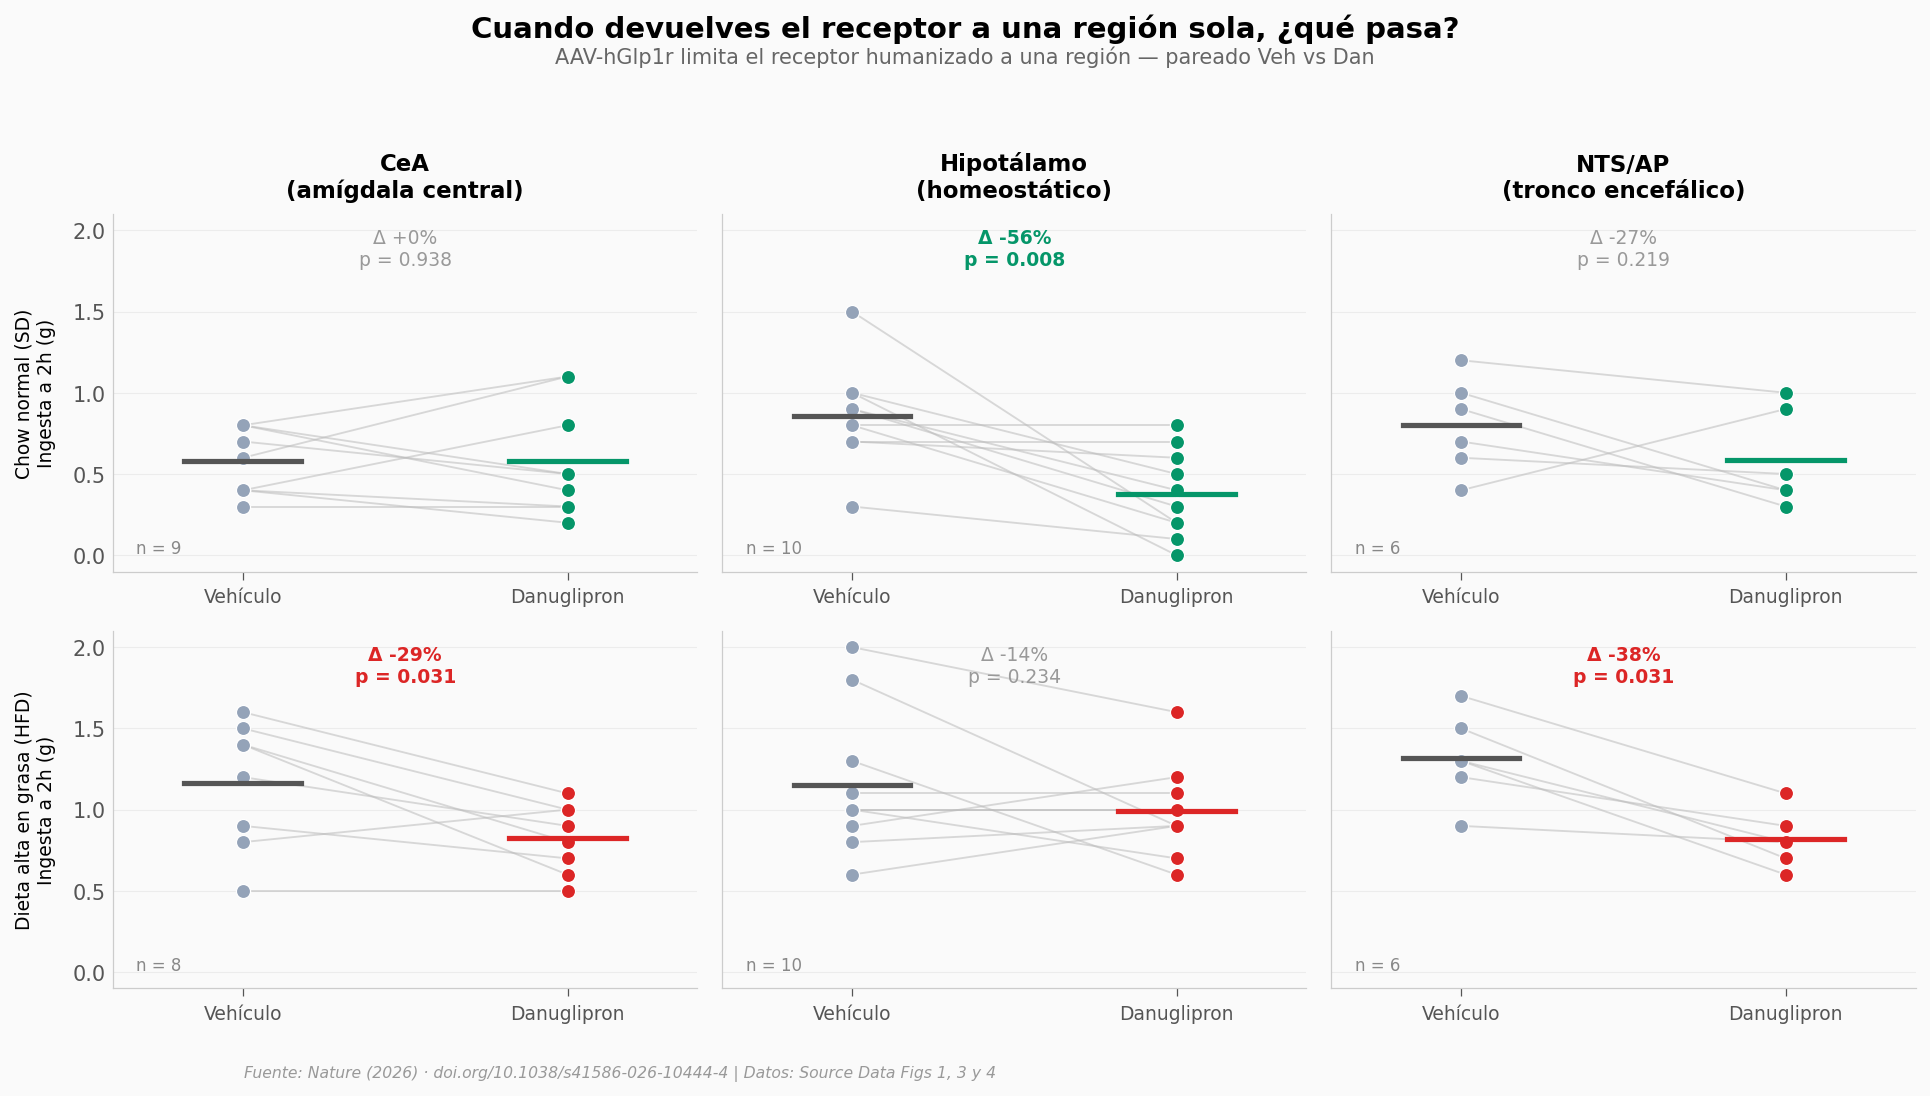

In [4]:
# Rescate AAV: comparar Veh vs Dan a 2h, pareado por mouse_id
combos = [('CeA', 'SD'), ('CeA', 'HFD'),
          ('Hypothalamus', 'SD'), ('Hypothalamus', 'HFD'),
          ('NTS/AP', 'SD'), ('NTS/AP', 'HFD')]

resultados_aav = []
for region, dieta in combos:
    sub = df_aav[(df_aav.region_aav == region) & (df_aav.dieta == dieta) &
                 (df_aav.tiempo == '2 hour')]
    veh = sub[sub.inyeccion == 'Vehicle'].set_index('mouse_id')['ingesta_g']
    dan = sub[sub.inyeccion == 'Danuglipron'].set_index('mouse_id')['ingesta_g']
    common = veh.index.intersection(dan.index)
    v = veh.loc[common].values
    d = dan.loc[common].values
    pct = (d.mean() - v.mean()) / v.mean() * 100
    w, p = stats.wilcoxon(d, v)
    resultados_aav.append({'region': region, 'dieta': dieta, 'n': len(common),
                            'veh_mean': v.mean(), 'dan_mean': d.mean(),
                            'pct_cambio': pct, 'p_wilcoxon': p, 'pares': list(zip(v, d))})

print(pd.DataFrame([{k: v for k, v in r.items() if k != 'pares'} for r in resultados_aav]).to_string(index=False))

# Plot: 3 columnas (CeA, Hypothalamus, NTS/AP) × 2 filas (SD, HFD)
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharey=True)
regiones_plot = ['CeA', 'Hypothalamus', 'NTS/AP']
dietas_plot = ['SD', 'HFD']
nombres_region = {'CeA': 'CeA\n(amígdala central)',
                  'Hypothalamus': 'Hipotálamo\n(homeostático)',
                  'NTS/AP': 'NTS/AP\n(tronco encefálico)'}
nombres_dieta = {'SD': 'Chow normal (SD)', 'HFD': 'Dieta alta en grasa (HFD)'}
color_dieta = {'SD': COLOR_HOMEOSTAT, 'HFD': COLOR_ALERTA}

for col, region in enumerate(regiones_plot):
    for row, dieta in enumerate(dietas_plot):
        ax = axes[row, col]
        r = next(x for x in resultados_aav if x['region'] == region and x['dieta'] == dieta)
        pares = r['pares']
        x_veh = np.full(len(pares), 0)
        x_dan = np.full(len(pares), 1)
        y_veh = [p[0] for p in pares]
        y_dan = [p[1] for p in pares]
        for yv, yd in pares:
            ax.plot([0, 1], [yv, yd], color='#BBBBBB', linewidth=0.9, alpha=0.55, zorder=2)
        ax.scatter(x_veh, y_veh, color='#94A3B8', s=46,
                   edgecolors='white', linewidths=0.6, zorder=5)
        ax.scatter(x_dan, y_dan, color=color_dieta[dieta], s=46,
                   edgecolors='white', linewidths=0.6, zorder=5)
        # Mean bars
        ax.plot([-0.18, 0.18], [r['veh_mean']] * 2, color='#555555', linewidth=2.5, zorder=6)
        ax.plot([0.82, 1.18], [r['dan_mean']] * 2, color=color_dieta[dieta], linewidth=2.5, zorder=6)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Vehículo', 'Danuglipron'], fontsize=9)
        ax.set_xlim(-0.4, 1.4)
        if col == 0:
            ax.set_ylabel(f'{nombres_dieta[dieta]}\nIngesta a 2h (g)', fontsize=9)
        if row == 0:
            ax.set_title(nombres_region[region], fontsize=11, fontweight='bold', pad=8)

        # Annotation p-value
        p = r['p_wilcoxon']
        pct = r['pct_cambio']
        label_p = f'p = {p:.3f}' if p >= 0.001 else 'p < 0.001'
        color_p = color_dieta[dieta] if p < 0.05 else '#999999'
        weight_p = 'bold' if p < 0.05 else 'normal'
        ax.text(0.5, 0.96, f'Δ {pct:+.0f}%\n{label_p}', transform=ax.transAxes,
                fontsize=9, color=color_p, fontweight=weight_p,
                ha='center', va='top')
        # n
        ax.text(0.04, 0.04, f'n = {r["n"]}', transform=ax.transAxes,
                fontsize=8, color='#888888', ha='left', va='bottom')

fig.suptitle('Cuando devuelves el receptor a una región sola, ¿qué pasa?',
             fontsize=14, fontweight='bold', y=1.06)
fig.text(0.5, 1.01, 'AAV-hGlp1r limita el receptor humanizado a una región — pareado Veh vs Dan',
         transform=fig.transFigure, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_rescate_aav.png', dpi=200, bbox_inches='tight')
plt.show()

La disociación es exacta. La amígdala central solo reduce la ingesta cuando hay comida palatable disponible — no toca el chow normal. El hipotálamo hace lo opuesto: reduce el chow, ignora la comida palatable. NTS/AP queda en una posición intermedia.

Para verlo en una sola imagen, podemos ordenar todas las combinaciones por % de reducción:

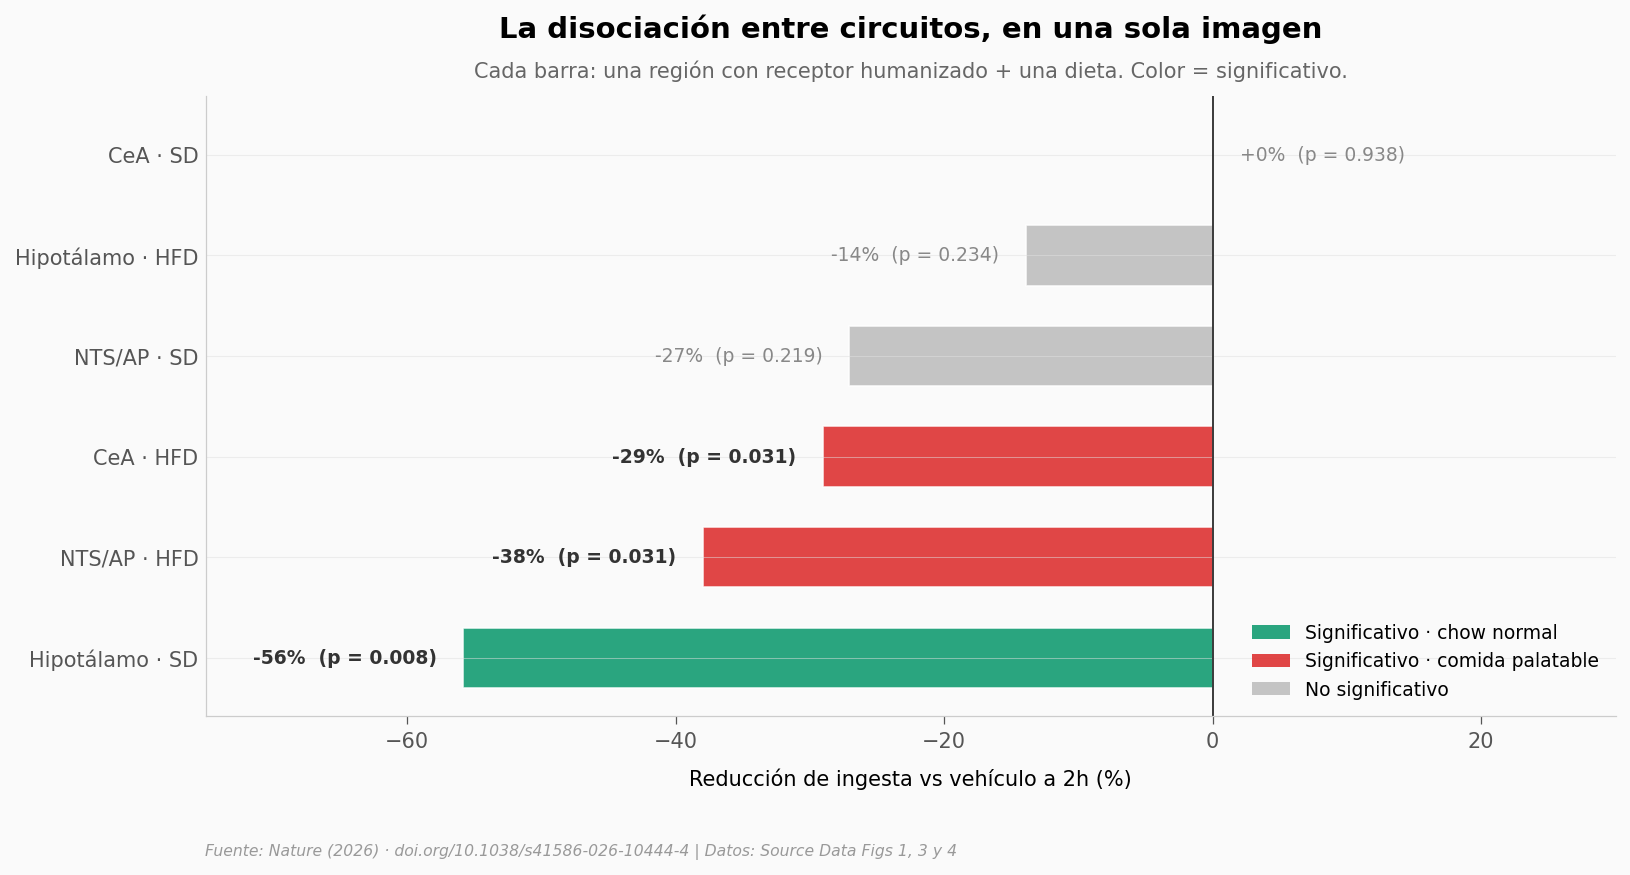

In [5]:
# Cleveland dot plot: % cambio ordenado, agrupado por dieta
ordenado = sorted(resultados_aav, key=lambda r: r['pct_cambio'])

fig, ax = plt.subplots(figsize=(11, 5.5))
# Traducir nombres de región al español para los labels visibles
nombre_region_es = {'Hypothalamus': 'Hipotálamo', 'CeA': 'CeA',
                    'NTS/AP': 'NTS/AP', 'DMH': 'DMH'}
labels = [f"{nombre_region_es.get(r['region'], r['region'])} · {r['dieta']}" for r in ordenado]
pcts = [r['pct_cambio'] for r in ordenado]
ps = [r['p_wilcoxon'] for r in ordenado]
colores = []
for r in ordenado:
    if r['p_wilcoxon'] < 0.05:
        colores.append(COLOR_ALERTA if r['dieta'] == 'HFD' else COLOR_HOMEOSTAT)
    else:
        colores.append('#BBBBBB')

y_pos = np.arange(len(ordenado))
ax.barh(y_pos, pcts, color=colores, alpha=0.85, edgecolor='white', linewidth=0.8, height=0.6)
ax.axvline(0, color='#333333', linewidth=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)

# Etiquetas con p-value
for i, (pct, p) in enumerate(zip(pcts, ps)):
    label_p = f'p = {p:.3f}' if p >= 0.001 else 'p<0.001'
    weight = 'bold' if p < 0.05 else 'normal'
    color = '#333333' if p < 0.05 else '#888888'
    x_label = pct + (2 if pct >= 0 else -2)
    ha = 'left' if pct >= 0 else 'right'
    ax.text(x_label, i, f'{pct:+.0f}%  ({label_p})',
            fontsize=9, color=color, fontweight=weight, va='center', ha=ha)

ax.set_xlabel('Reducción de ingesta vs vehículo a 2h (%)', fontsize=10)
ax.set_title('La disociación entre circuitos, en una sola imagen',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Cada barra: una región con receptor humanizado + una dieta. Color = significativo.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-75, 30)

# Leyenda manual de color
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_HOMEOSTAT, alpha=0.85, label='Significativo · chow normal'),
    Patch(facecolor=COLOR_ALERTA, alpha=0.85, label='Significativo · comida palatable'),
    Patch(facecolor='#BBBBBB', alpha=0.85, label='No significativo'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_disociacion_circuitos.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Liraglutide reduce la ingesta de forma similar en ratones WT y S33W | ✅ | WT: −51.9% · S33W: −56.7% (a 2h, vs salino). El péptido se une a ambos receptores. |
| Danuglipron y Orforglipron solo reducen ingesta en S33W (no en WT) | ✅ | Dan WT: +10.6% (sin efecto) · Dan S33W: −51.5%. Orf WT: −1.2% · Orf S33W: −57.6%. |
| Danuglipron activa más Fos en la amígdala central de ratones S33W que de WT | ✅ | CeA WT 0.67 vs S33W 0.90 · Mann-Whitney p=0.030 · d=0.45 (efecto medio). Direccional, modesto. |
| El DMH (hipotálamo dorsomedial) NO se activa más en S33W | ✅ | WT 1.41 vs S33W 1.31 · p=0.78 · n.s. Probable saturación por receptor endógeno. |
| El rescate del receptor en CeA basta para que la droga reduzca comida palatable | ✅ | AAV-hGlp1r en CeA bajo HFD: Δ −29% · p=0.031 · Cohen's d pareado = -1.03 · n=8 ratones pareados. |
| El rescate del receptor en CeA NO afecta la ingesta de chow normal | ✅ | Misma intervención bajo SD: Δ 0% · p=0.94. Confirma la especificidad por comida palatable. |
| El hipotálamo controla la ingesta homeostática (chow), no la hedónica | ✅ | AAV-hGlp1r en hipotálamo: SD Δ −56% (p=0.008, d_paired = -1.12) vs HFD Δ −14% (n.s., d_paired = -0.39). |
| El circuito identificado opera igual en humanos | ⚠️ | El modelo S33W humaniza UN aminoácido del receptor. La arquitectura del circuito en cerebros humanos está por confirmar. |

> **Limitaciones.** (1) Todos los experimentos son en ratones modificados genéticamente — la extrapolación al cerebro humano requiere validación independiente. (2) Las medidas de Fos son indirectas; no prueban que las neuronas Glp1r+ de la CeA sean el motor del efecto (el paper original lo aborda con optogenética — encender o apagar neuronas con luz láser — pero esa parte no está reproducida en este notebook). (3) Los pareados de la Fig. 4 funcionan dentro de cada ratón pero los n por celda son chicos (n=6–10), así que el efecto se replicará mejor con réplicas independientes.

## Ahora tú

Tres preguntas para abrir el dataset:

1. **¿Cómo cambia el efecto de Danuglipron con el tiempo (1h, 2h, 4h)?** Repite el cálculo de la primera gráfica con `TIEMPO_FOCO = '1hr'` o `'4hr'`. ¿La especificidad por S33W aparece desde el primer momento, o se afila con el tiempo?
2. **El control de virus (AAV-mCherry) — ¿se comporta como el AAV activo en alguna condición?** Filtra `df_aav[df_aav.virus=='AAV-mCherry']` y compáralo con el grupo `Hypothalamus mCherry`. ¿Es un buen control?
3. **¿Hay outliers que arrastren las medias en Fos?** Reemplaza el Mann-Whitney por un test robusto (e.g. permutación o bootstrap) y mira si la conclusión del CeA aguanta.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿cómo evoluciona el efecto de Danuglipron a lo largo del tiempo?

for t in ['1hr', '2hr', '4hr']:
    print(f'\n=== {t} ===')
    for geno in ['WT', 'S33W']:
        ctrl = df_ingesta[(df_ingesta.tiempo==t)&(df_ingesta.droga=='Danuglipron')&
                          (df_ingesta.genotipo==geno)&(df_ingesta.condicion=='control')]
        drug = df_ingesta[(df_ingesta.tiempo==t)&(df_ingesta.droga=='Danuglipron')&
                          (df_ingesta.genotipo==geno)&(df_ingesta.condicion=='droga')]
        if len(ctrl) and len(drug):
            m_c = ctrl.media_ingesta_g.values[0]
            m_d = drug.media_ingesta_g.values[0]
            pct = (m_d - m_c) / m_c * 100
            print(f'  {geno:5}: ctrl={m_c:.2f}g  drug={m_d:.2f}g  cambio={pct:+.1f}%')


=== 1hr ===
  WT   : ctrl=0.25g  drug=0.21g  cambio=-15.0%
  S33W : ctrl=0.34g  drug=0.14g  cambio=-58.8%

=== 2hr ===
  WT   : ctrl=0.71g  drug=0.78g  cambio=+10.6%
  S33W : ctrl=0.89g  drug=0.43g  cambio=-51.5%

=== 4hr ===
  WT   : ctrl=1.68g  drug=1.74g  cambio=+3.3%
  S33W : ctrl=1.73g  drug=1.22g  cambio=-29.3%


---

## Fuentes

**Paper**: [A brain reward circuit inhibited by next-generation weight-loss drugs in mice](https://doi.org/10.1038/s41586-026-10444-4)  
*Nature, 2026-05-06*

**Source Data** (Supplementary del mismo DOI):
- [Source Data Figure 1 — Body weight and food intake responses to GLP1RAs in humanized vs WT mice](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10444-4/MediaObjects/41586_2026_10444_MOESM5_ESM.xlsx)
- [Source Data Figure 3 — Fos activation in brain regions (DMH, NTS, AP, CeA)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10444-4/MediaObjects/41586_2026_10444_MOESM7_ESM.xlsx)
- [Source Data Figure 4 — AAV rescue experiments (Hypothalamus, DMH, NTS/AP, CeA) under SD and HFD diets](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10444-4/MediaObjects/41586_2026_10444_MOESM8_ESM.xlsx)

**Código de análisis**: [glp1r-reward-circuit — Code repository for analysis](https://github.com/UVACircMetNeuLab/glp1r-reward-circuit)

*17 afirmaciones del notebook verificadas contra estas fuentes*

---

**Notebook**: parte de [Ciencia a Mordiscos · El Lab](https://cienciaamordiscos.com).
**Licencia**: CC BY 4.0 (notebook + texto). Datos: ver licencia del paper original.